### LAB EXERCISE - 2 IMDB MOVIE REVIEWS

In [7]:
# Various NLP preprocessing tasks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re
import spacy

from bs4 import BeautifulSoup
from wordcloud import WordCloud, STOPWORDS

from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk import pos_tag
from nltk.wsd import lesk
from nltk.chunk import ne_chunk
from nltk.tree import Tree


# Download required NLTK resources
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     /Users/bryanlim/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /Users/bryanlim/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /Users/bryanlim/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /Users/bryanlim/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /Users/bryanlim/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_da

True

In [8]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from afinn import Afinn

In [9]:
# Remove the HTML tag
df = pd.read_csv('IMDB Dataset.csv')[['review']]
df['html_review'] = df['review'].apply(lambda x: BeautifulSoup(x, "html.parser").get_text())

print(df[['review','html_review' ]].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                         html_review  
0  One of the other reviewers has mentioned that ...  
1  A wonderful little production. The filming tec...  
2  I thought this was a wonderful way to spend ti...  
3  Basically there's a family where a little boy ...  
4  Petter Mattei's "Love in the Time of Money" is...  


In [10]:
# Initialize analyzers
vader_analyzer = SentimentIntensityAnalyzer()
afinn_analyzer = Afinn()

# TextBlob Sentiment Analysis
# Ranges from -1 (very negative) to +1 (very positive)
df['textblob_polarity'] = df['html_review'].apply(lambda x: TextBlob(x).sentiment.polarity)
# Ranges from 0 (objective) to 1 (subjective)
df['textblob_subjectivity'] = df['html_review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# VADER Sentiment Analysis
# Proportions of negative, neutral, and positive sentiment
# Normalized score from -1 to +1 summarizing the sentiment
vader_scores = df['html_review'].apply(lambda x: vader_analyzer.polarity_scores(x))
df['vader_neg'] = vader_scores.apply(lambda x: x['neg'])
df['vader_neu'] = vader_scores.apply(lambda x: x['neu'])
df['vader_pos'] = vader_scores.apply(lambda x: x['pos'])
df['vader_compound'] = vader_scores.apply(lambda x: x['compound'])

# AFINN Sentiment Analysis (A total sentiment score (sum of term scores). More positive = more positive sentiment)
df['afinn_score'] = df['html_review'].apply(lambda x: afinn_analyzer.score(x))

                                         html_review  textblob_polarity  \
0  One of the other reviewers has mentioned that ...           0.023433   
1  A wonderful little production. The filming tec...           0.109722   
2  I thought this was a wonderful way to spend ti...           0.354008   
3  Basically there's a family where a little boy ...          -0.057813   
4  Petter Mattei's "Love in the Time of Money" is...           0.217952   

   vader_compound  afinn_score  
0         -0.9916        -40.0  
1          0.9670         13.0  
2          0.9519         21.0  
3         -0.9213         -8.0  
4          0.9744         28.0  


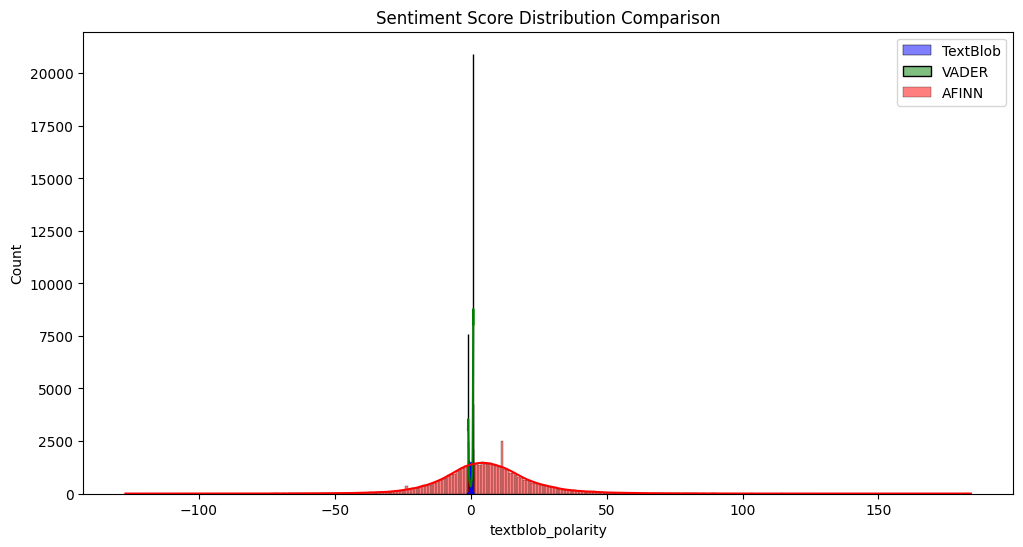

In [11]:
# View the textblob_polarity, vader_compound, afinn_score
print(df[['html_review', 'textblob_polarity', 'vader_compound', 'afinn_score']].head())
# Compare sentiment distributions
plt.figure(figsize=(12, 6))
sns.histplot(df['textblob_polarity'], color='blue', label='TextBlob', kde=True)
sns.histplot(df['vader_compound'], color='green', label='VADER', kde=True)
sns.histplot(df['afinn_score'], color='red', label='AFINN', kde=True)
plt.legend()
plt.title('Sentiment Score Distribution Comparison')
plt.show()